In [15]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import sys
sys.path.insert(0, "../src")
from gait.loader import load_device

W = pd.read_parquet("../data/processed/windows.parquet")

W["log_v"] = np.log(W["speed_ms"])
W["log_L"] = np.log(W["step_len_m"])
W["log_f"] = np.log(W["step_freq_spm"] / 60)
W["t10"]   = W["moving_s"] / 600

mov = W.groupby("activity_id")["moving_s"].max()
L = W[W["activity_id"].isin(mov[mov >= 3600].index)].dropna(subset=["grad_pct"]).copy()
print(L["activity_id"].nunique(), "long runs,", len(L), "windows")

85 long runs, 16198 windows


In [2]:
FORMULA = "log_L ~ t10 + log_v + grad_pct"

def run_slopes(df, formula=FORMULA, min_windows=40):
    out = {}
    for aid, d in df.groupby("activity_id"):
        if len(d) < min_windows:
            continue
        out[aid] = smf.ols(formula, data=d).fit().params["t10"]
    return pd.Series(out)

def summarise(s, label):
    t, p = stats.ttest_1samp(s, 0)
    ci = stats.t.interval(.95, len(s)-1, loc=s.mean(), scale=stats.sem(s))
    print(f"{label:22s} runs={len(s):3d}  {100*s.mean():+.3f}%/10min  "
          f"CI [{100*ci[0]:+.3f}, {100*ci[1]:+.3f}]  p={p:.3f}")

summarise(run_slopes(L), "all, incl. warm-up")
summarise(run_slopes(L[L["moving_s"] <  1800]), "first 30 min")
summarise(run_slopes(L[L["moving_s"] >= 1800]), "after 30 min")

all, incl. warm-up     runs= 85  +0.098%/10min  CI [+0.055, +0.141]  p=0.000
first 30 min           runs= 85  +0.549%/10min  CI [+0.441, +0.657]  p=0.000
after 30 min           runs= 85  -0.018%/10min  CI [-0.073, +0.036]  p=0.507


In [3]:
post = L[L["moving_s"] >= 1800]

specs = [
    ("No controls",                L,    "log_L ~ t10"),
    ("+ speed",                    L,    "log_L ~ t10 + log_v"),
    ("+ speed, gradient",          L,    "log_L ~ t10 + log_v + grad_pct"),
    ("+ speed, gradient, HR",      L,    "log_L ~ t10 + log_v + grad_pct + hr"),
    ("Post-warm-up, no controls",  post, "log_L ~ t10"),
    ("Post-warm-up + speed, grad", post, "log_L ~ t10 + log_v + grad_pct"),
    ("Post-warm-up + all three",   post, "log_L ~ t10 + log_v + grad_pct + hr"),
]

rows = []
for label, df, f in specs:
    s = run_slopes(df, f)
    t, p = stats.ttest_1samp(s, 0)
    ci = stats.t.interval(.95, len(s)-1, loc=s.mean(), scale=stats.sem(s))
    rows.append(dict(spec=label, n=len(s), mean=100*s.mean(),
                     lo=100*ci[0], hi=100*ci[1], p=p))

T = pd.DataFrame(rows)
print(T.round(3).to_string(index=False))

post_slopes = run_slopes(post, "log_L ~ t10 + log_v + grad_pct") * 100

                      spec  n   mean     lo    hi     p
               No controls 85  0.854  0.508 1.200 0.000
                   + speed 85  0.087  0.042 0.132 0.000
         + speed, gradient 85  0.098  0.055 0.141 0.000
     + speed, gradient, HR 85  0.068  0.024 0.111 0.003
 Post-warm-up, no controls 85  0.658  0.036 1.281 0.039
Post-warm-up + speed, grad 85 -0.018 -0.073 0.036 0.507
  Post-warm-up + all three 85 -0.040 -0.095 0.015 0.155


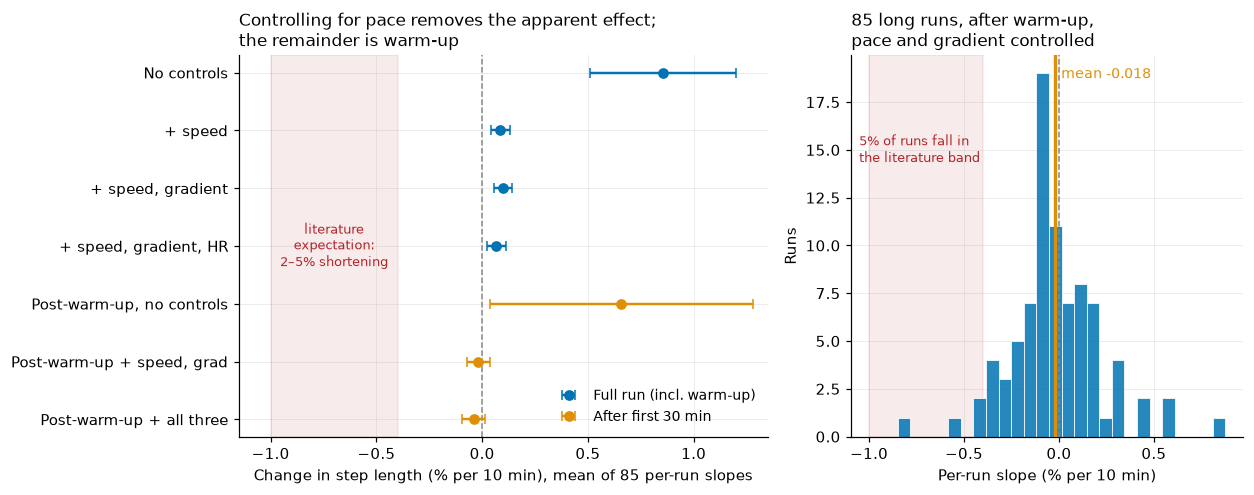

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110, "savefig.dpi":200, "font.size":10,
    "axes.spines.top":False, "axes.spines.right":False, "axes.grid":True,
    "grid.alpha":0.25, "grid.linewidth":0.6, "axes.axisbelow":True})

BLUE, ORANGE, RED = "#0173B2", "#DE8F05", "#B3242B"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                               gridspec_kw={"width_ratios":[1.35, 1]})

y = np.arange(len(T))[::-1]
is_post = T["spec"].str.startswith("Post")
ax1.axvspan(-1.0, -0.40, color=RED, alpha=.09, zorder=0)
ax1.text(-0.70, 3.0, "literature\nexpectation:\n2–5% shortening",
         color=RED, fontsize=8.5, ha="center", va="center")
ax1.axvline(0, color="#888", ls="--", lw=1, zorder=1)

for mask, lab, c in [(~is_post, "Full run (incl. warm-up)", BLUE),
                     (is_post,  "After first 30 min",       ORANGE)]:
    ax1.errorbar(T.loc[mask, "mean"], y[mask.values],
                 xerr=[T.loc[mask,"mean"] - T.loc[mask,"lo"],
                       T.loc[mask,"hi"]  - T.loc[mask,"mean"]],
                 fmt="o", ms=6, capsize=3, lw=1.6, color=c, label=lab, zorder=3)

ax1.set_yticks(y); ax1.set_yticklabels(T["spec"]); ax1.set_xlim(-1.15, 1.35)
ax1.set_xlabel("Change in step length (% per 10 min), mean of 85 per-run slopes")
ax1.set_title("Controlling for pace removes the apparent effect;\n"
              "the remainder is warm-up", loc="left", fontsize=11)
ax1.legend(frameon=False, fontsize=9, loc="lower right")

ax2.axvspan(-1.0, -0.40, color=RED, alpha=.09, zorder=0)
ax2.hist(post_slopes, bins=26, color=BLUE, alpha=.85,
         edgecolor="white", linewidth=.6, zorder=2)
ax2.axvline(0, color="#888", ls="--", lw=1, zorder=3)
ax2.axvline(post_slopes.mean(), color=ORANGE, lw=2.2, zorder=5)
ax2.text(post_slopes.mean()+.03, ax2.get_ylim()[1]*.94,
         f"mean {post_slopes.mean():+.3f}", color=ORANGE, fontsize=9)
ax2.set_xlabel("Per-run slope (% per 10 min)"); ax2.set_ylabel("Runs")
ax2.set_title("85 long runs, after warm-up,\npace and gradient controlled",
              loc="left", fontsize=11)
ax2.text(.02, .72, f"{(post_slopes < -0.40).mean()*100:.0f}% of runs fall in\n"
         "the literature band", transform=ax2.transAxes, fontsize=8.5, color=RED)

fig.tight_layout()
fig.savefig("../figures/fig04_fatigue.png", bbox_inches="tight")

In [6]:
RACE = "21307189990"                       # 13 Sep 2026, 21.1 km in 1:47
R = W[W["activity_id"] == RACE].sort_values("win").copy()
R["km"] = R["dist_delta_m"].cumsum() / 1000
R["log_f"] = np.log(R["step_freq_spm"] / 60)

W["log_f"] = np.log(W["step_freq_spm"] / 60)
D = W.dropna(subset=["grad_pct"])
def fitA(y):
    return smf.ols(f"{y} ~ log_v + grad_pct", data=D).fit(
        cov_type="cluster", cov_kwds={"groups": D["activity_id"]})
mL, mf = fitA("log_L"), fitA("log_f")

for m, col, hat in [(mL, "log_L", "logL_hat"), (mf, "log_f", "logf_hat")]:
    R[hat] = (m.params["Intercept"] + m.params["log_v"]*R["log_v"]
              + m.params["grad_pct"]*R["grad_pct"])

offL = (R["log_L"] - R["logL_hat"]).mean()
offf = (R["log_f"] - R["logf_hat"]).mean()
print(f"level offset vs training model: step length {100*offL:+.2f}%, cadence {100*offf:+.2f}%")

R["L_pred"] = np.exp(R["logL_hat"] + offL)
R["f_pred"] = np.exp(R["logf_hat"] + offf) * 60
R["resid_pct"] = 100 * (R["log_L"] - (R["logL_hat"] + offL))

for lo in (0, 3, 5):
    d = R[R["km"] >= lo]
    m = smf.ols("resid_pct ~ km", data=d).fit()
    print(f"after {lo} km: {m.params['km']:+.4f} %/km (p={m.pvalues['km']:.3f})")

level offset vs training model: step length -3.88%, cadence +3.88%
after 0 km: +0.0959 %/km (p=0.000)
after 3 km: +0.0653 %/km (p=0.000)
after 5 km: +0.0553 %/km (p=0.000)


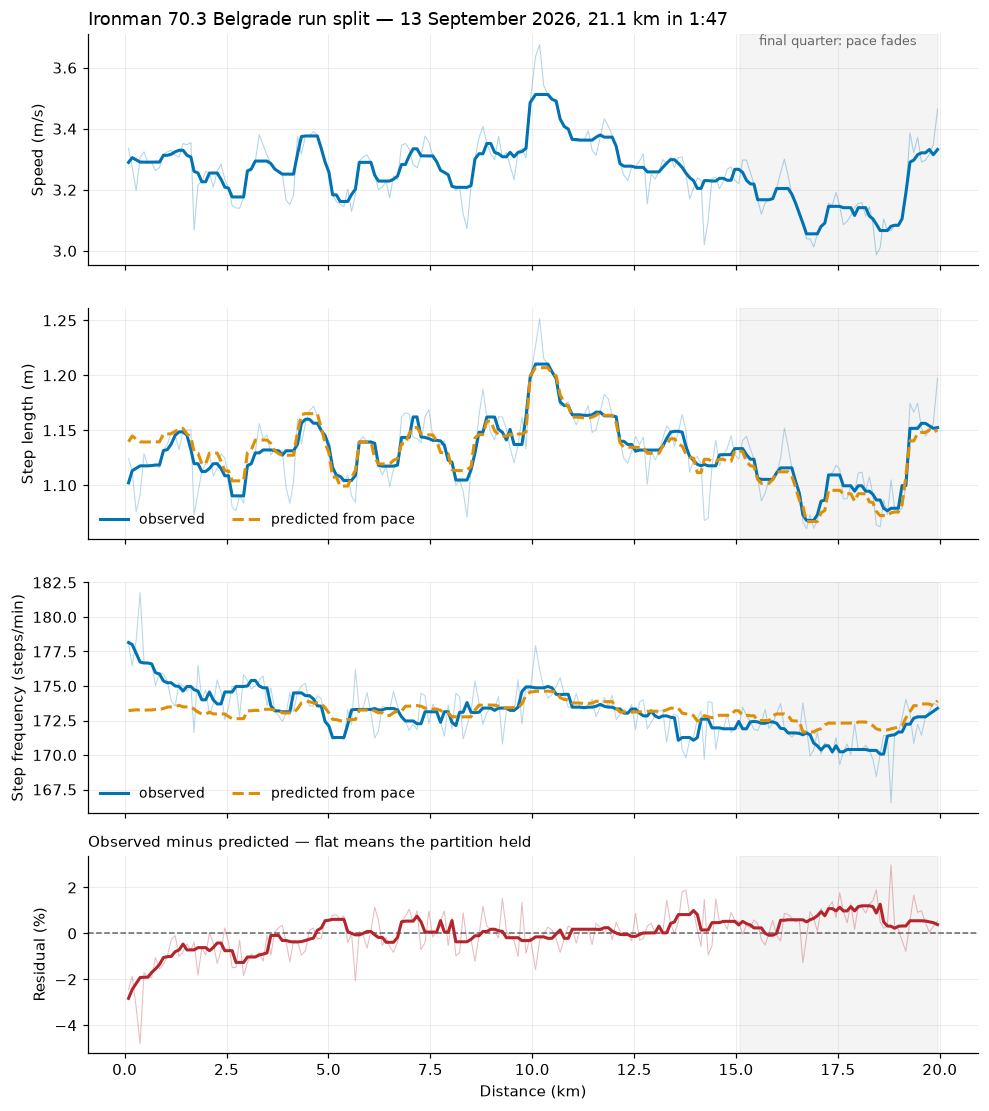

In [7]:
BLUE, ORANGE, GREY, RED = "#0173B2", "#DE8F05", "#666666", "#B3242B"
smooth = lambda s: s.rolling(7, center=True, min_periods=2).median()

fig, axes = plt.subplots(4, 1, figsize=(9, 10.2), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 0.85]})
x = R["km"]

axes[0].plot(x, R["speed_ms"], lw=.7, color=BLUE, alpha=.30)
axes[0].plot(x, smooth(R["speed_ms"]), lw=2, color=BLUE)
axes[0].set_ylabel("Speed (m/s)")
axes[0].set_title("Ironman 70.3 Belgrade run split — 13 September 2026, 21.1 km in 1:47",
                  loc="left", fontsize=11.5)

for ax, obs, pred, lab, unit in [
        (axes[1], "step_len_m",    "L_pred", "Step length",    "m"),
        (axes[2], "step_freq_spm", "f_pred", "Step frequency", "steps/min")]:
    ax.plot(x, R[obs], lw=.7, color=BLUE, alpha=.28)
    ax.plot(x, smooth(R[obs]),  lw=2, color=BLUE,   label="observed", zorder=4)
    ax.plot(x, smooth(R[pred]), lw=2, color=ORANGE, ls="--",
            label="predicted from pace", zorder=5)
    ax.set_ylabel(f"{lab} ({unit})")
    ax.legend(frameon=False, fontsize=9, loc="lower left", ncol=2)

axes[3].axhline(0, color=GREY, ls="--", lw=1)
axes[3].plot(x, R["resid_pct"], lw=.7, color=RED, alpha=.30)
axes[3].plot(x, smooth(R["resid_pct"]), lw=2, color=RED)
axes[3].set_ylabel("Residual (%)")
axes[3].set_xlabel("Distance (km)")
axes[3].set_title("Observed minus predicted — flat means the partition held",
                  loc="left", fontsize=10)

for ax in axes:
    ax.axvspan(15.1, x.max(), color=GREY, alpha=.07, zorder=0)
axes[0].text(17.5, axes[0].get_ylim()[1], "final quarter: pace fades",
             fontsize=8.5, color=GREY, ha="center", va="top")

fig.tight_layout()
fig.savefig("../figures/fig05_race.png", bbox_inches="tight")

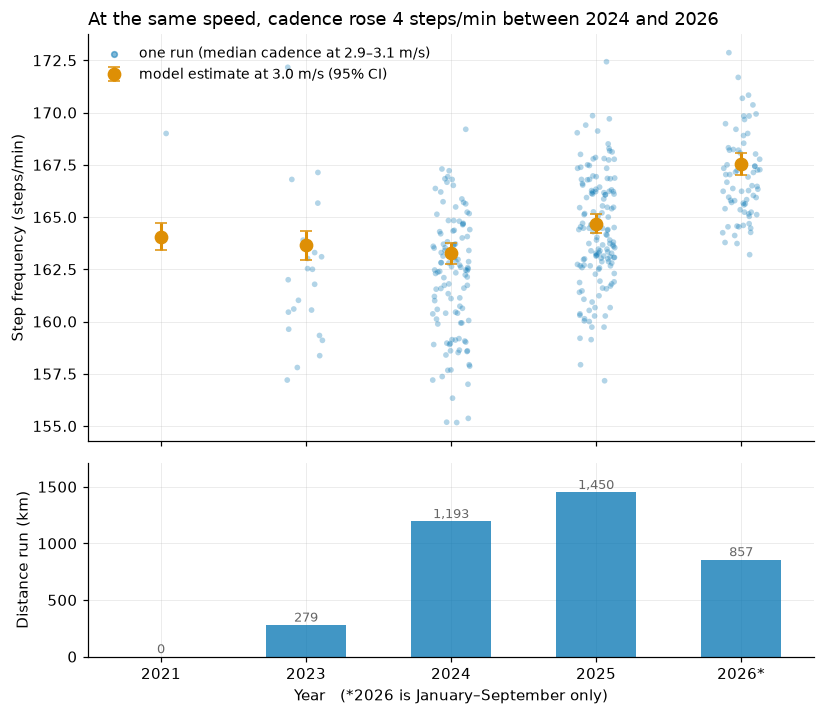

In [8]:
band = D[(D["speed_ms"] > 2.9) & (D["speed_ms"] < 3.1)]
per_act = band.groupby(["year", "activity_id"])["step_freq_spm"].median().reset_index()

def cadence_at(d, v=3.0):
    m = smf.ols("log_f ~ log_v + grad_pct", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["activity_id"]})
    x = np.array([1, np.log(v), 0])
    mu, se = x @ m.params.values, np.sqrt(x @ m.cov_params().values @ x)
    return np.exp(mu)*60, np.exp(mu - 1.96*se)*60, np.exp(mu + 1.96*se)*60

est = pd.DataFrame([dict(year=y, **dict(zip(("m","lo","hi"), cadence_at(d))))
                    for y, d in D.groupby("year")])

summary = pd.read_parquet("../data/processed/activity_summary.parquet")
summary["year"] = pd.to_datetime(summary["start_time"]).dt.year
vol = summary[summary["year"] >= 2023].groupby("year")["distance_m"].sum() / 1000

yrs = sorted(per_act["year"].unique()); x = np.arange(len(yrs))
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(7.6, 6.6), sharex=True,
                              gridspec_kw={"height_ratios": [2.1, 1]})

rng = np.random.default_rng(0)
for i, y in enumerate(yrs):
    v = per_act.loc[per_act.year == y, "step_freq_spm"].values
    ax.scatter(i + rng.uniform(-.13, .13, len(v)), v, s=14,
               color=BLUE, alpha=.30, edgecolors="none", zorder=2)

ax.errorbar(x, est["m"], yerr=[est["m"]-est["lo"], est["hi"]-est["m"]],
            fmt="o", ms=8, capsize=4, lw=2, color=ORANGE, zorder=5,
            label="model estimate at 3.0 m/s (95% CI)")
ax.scatter([], [], s=14, color=BLUE, alpha=.5,
           label="one run (median cadence at 2.9–3.1 m/s)")
ax.set_ylabel("Step frequency (steps/min)")
ax.set_title("At the same speed, cadence rose 4 steps/min between 2024 and 2026",
             loc="left", fontsize=11.5)
ax.legend(frameon=False, fontsize=9, loc="upper left")

ax2.bar(x, [vol.get(y, 0) for y in yrs], color=BLUE, alpha=.75, width=.55)
ax2.set_ylabel("Distance run (km)")
ax2.set_xticks(x)
ax2.set_xticklabels([f"{y}*" if y == 2026 else str(y) for y in yrs])
ax2.set_xlabel("Year   (*2026 is January–September only)")
for i, y in enumerate(yrs):
    ax2.text(i, vol.get(y, 0) + 30, f"{vol.get(y,0):,.0f}",
             ha="center", fontsize=8.5, color=GREY)
ax2.set_ylim(0, vol.max() * 1.18)

fig.tight_layout()
fig.savefig("../figures/fig06_cadence_trend.png", bbox_inches="tight")

In [9]:
def load_device(path):
    """Extract recording device and paired sensors from one FIT file."""
    path = Path(path)
    opener = gzip.open if path.suffix == ".gz" else open

    watch, serial, sensors = None, None, set()
    with opener(path, "rb") as f:
        with fitdecode.FitReader(f) as fit:
            for frame in fit:
                if not isinstance(frame, fitdecode.FitDataMessage):
                    continue
                if frame.name == "file_id" and watch is None:
                    watch = _first_value(frame, ["garmin_product", "product"])
                    serial = frame.get_value("serial_number", fallback=None)
                elif frame.name == "device_info":
                    product = _first_value(frame, ["garmin_product", "product"])
                    dtype = _first_value(frame, ["antplus_device_type", "device_type"])
                    if product is not None or dtype is not None:
                        sensors.add(f"{product}:{dtype}")

    return {
        "activity_id": path.name.split(".")[0],
        "watch": watch,
        "serial": serial,
        "sensors": "|".join(sorted(str(s) for s in sensors)),
    }

In [12]:
from pathlib import Path
from gait.loader import load_device

RAW = Path("../data/raw/activities")
ids = set(W["activity_id"])

rows = []
for p in RAW.glob("*.fit*"):
    if p.name.split(".")[0] in ids:
        rows.append(load_device(p))

dev = pd.DataFrame(rows)
dev["footpod"] = dev["sensors"].str.contains("stride_speed_distance")
dev["hrm_pro"]  = dev["sensors"].str.contains("hrm_pro")

dev = dev.merge(summary[["activity_id", "year"]], on="activity_id", how="left")
print(dev.groupby(["year", "watch"]).size().to_string())
print()
print(dev.groupby("year")[["footpod", "hrm_pro"]].mean().round(3).to_string())

dev.to_parquet("../data/processed/device_info.parquet", index=False)

year  watch
2021  fr235      2
2023  fr235      5
      fr255     31
2024  fr255    128
2025  fr255    148
2026  fr255     88

      footpod  hrm_pro
year                  
2021    0.000    0.000
2023    0.528    0.861
2024    0.727    0.727
2025    0.000    0.000
2026    0.045    0.045


In [13]:
band = W[(W["speed_ms"] > 2.9) & (W["speed_ms"] < 3.1)].merge(
    dev[["activity_id", "footpod", "watch"]], on="activity_id", how="left")
print(band.groupby(["year", "footpod"])["step_freq_spm"].agg(["median", "size"]).to_string())

                  median  size
year footpod                  
2021 False    169.000000     1
2023 False    161.595833   112
     True     157.683333   166
2024 False    163.766667   643
     True     161.816667   824
2025 False    163.866667  4507
2026 False    166.466667  2532
     True     169.900000    44


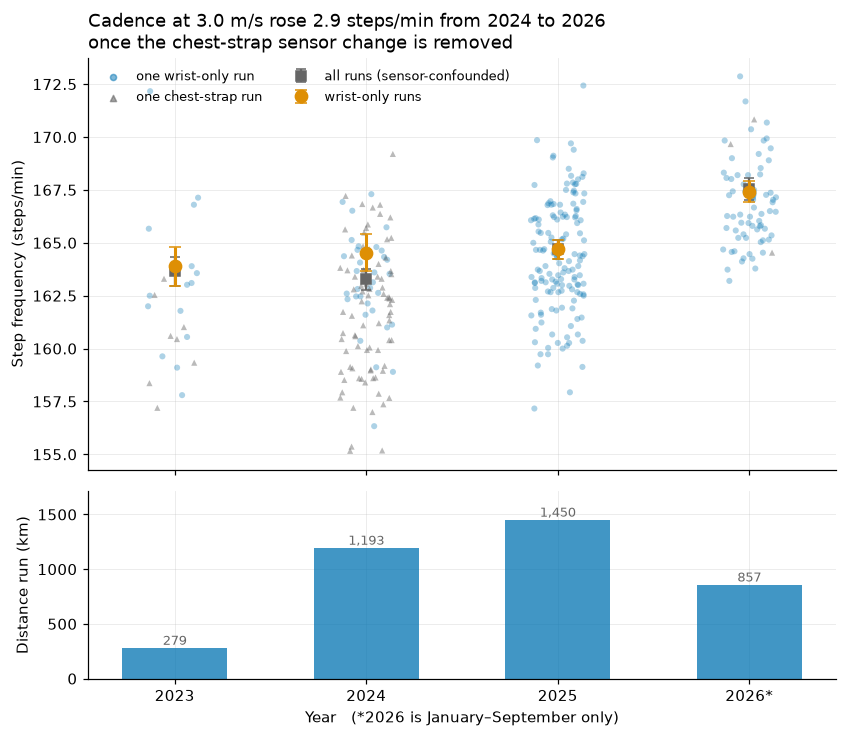

In [16]:
W = W.merge(dev[["activity_id", "footpod"]], on="activity_id", how="left")
D = W[W["year"] >= 2023].dropna(subset=["grad_pct", "footpod"]).copy()

est = pd.DataFrame([
    dict(year=y,
         **dict(zip(("all","all_lo","all_hi"), cadence_at(d)[:3])),
         **dict(zip(("w","w_lo","w_hi"),       cadence_at(d[~d["footpod"]])[:3])))
    for y, d in D.groupby("year")])

band = D[(D["speed_ms"] > 2.9) & (D["speed_ms"] < 3.1)]
per_act = band.groupby(["year","activity_id","footpod"])["step_freq_spm"].median().reset_index()

yrs = sorted(per_act["year"].unique()); x = np.arange(len(yrs))
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(7.8, 6.8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})
rng = np.random.default_rng(0)
for i, y in enumerate(yrs):
    for fp, mk, colr, al in [(False, "o", BLUE, .32), (True, "^", GREY, .45)]:
        v = per_act.loc[(per_act.year == y) & (per_act.footpod == fp), "step_freq_spm"].values
        if len(v):
            ax.scatter(i + rng.uniform(-.14, .14, len(v)), v, s=16, marker=mk,
                       color=colr, alpha=al, edgecolors="none", zorder=2)

ax.errorbar(x, est["all"], yerr=[est["all"]-est["all_lo"], est["all_hi"]-est["all"]],
            fmt="s", ms=6, capsize=3, lw=1.5, color=GREY, zorder=4,
            label="all runs (sensor-confounded)")
ax.errorbar(x, est["w"], yerr=[est["w"]-est["w_lo"], est["w_hi"]-est["w"]],
            fmt="o", ms=8, capsize=4, lw=2, color=ORANGE, zorder=5, label="wrist-only runs")
ax.scatter([], [], s=16, color=BLUE, alpha=.5, label="one wrist-only run")
ax.scatter([], [], s=16, marker="^", color=GREY, alpha=.6, label="one chest-strap run")
ax.set_ylabel("Step frequency (steps/min)")
ax.set_title("Cadence at 3.0 m/s rose 2.9 steps/min from 2024 to 2026\n"
             "once the chest-strap sensor change is removed", loc="left", fontsize=11.5)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", ncol=2)

ax2.bar(x, [vol.get(y, 0) for y in yrs], color=BLUE, alpha=.75, width=.55)
ax2.set_ylabel("Distance run (km)"); ax2.set_xticks(x)
ax2.set_xticklabels([f"{y}*" if y == 2026 else str(y) for y in yrs])
ax2.set_xlabel("Year   (*2026 is January–September only)")
for i, y in enumerate(yrs):
    ax2.text(i, vol.get(y, 0) + 30, f"{vol.get(y,0):,.0f}", ha="center", fontsize=8.5, color=GREY)
ax2.set_ylim(0, vol.max() * 1.18)

fig.tight_layout()
fig.savefig("../figures/fig06_cadence_trend.png", bbox_inches="tight")

In [17]:
D = W.dropna(subset=["grad_pct"]).copy()

def beta_L(d):
    m = smf.ols("log_L ~ log_v + grad_pct", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["activity_id"]})
    return m.params["log_v"], m.bse["log_v"], len(d), d["activity_id"].nunique()

subsets = [
    ("primary (all)",       D),
    ("retained >= 0.70",    D[D["retained"] >= 0.70]),
    ("retained >= 0.80",    D[D["retained"] >= 0.80]),
    ("1 Hz only",           D[D["is_1hz"]]),
    ("wrist-only",          D[~D["footpod"].fillna(False)]),
    ("flat |grad| < 1%",    D[D["grad_pct"].abs() < 1]),
]
for label, d in subsets:
    b, se, n, a = beta_L(d)
    print(f"{label:22s} beta_L={b:.4f} (SE {se:.4f})  {n:6d} windows, {a:3d} runs")

mov = W.groupby("activity_id")["moving_s"].max()
post = D[D["activity_id"].isin(mov[mov >= 3600].index) & (D["moving_s"] >= 1800)]

for label, d in [("primary", post),
                 ("retained >= 0.70", post[post["retained"] >= 0.70]),
                 ("retained >= 0.80", post[post["retained"] >= 0.80]),
                 ("wrist-only",       post[~post["footpod"].fillna(False)])]:
    s = run_slopes(d)
    t, p = stats.ttest_1samp(s, 0)
    ci = stats.t.interval(.95, len(s)-1, loc=s.mean(), scale=stats.sem(s))
    print(f"{label:18s} {100*s.mean():+.3f}%/10min  "
          f"CI [{100*ci[0]:+.3f}, {100*ci[1]:+.3f}]  p={p:.3f}  ({len(s)} runs)")

primary (all)          beta_L=0.8781 (SE 0.0062)   37315 windows, 370 runs
retained >= 0.70       beta_L=0.8789 (SE 0.0064)   36368 windows, 359 runs
retained >= 0.80       beta_L=0.8796 (SE 0.0070)   34456 windows, 343 runs
1 Hz only              beta_L=0.8777 (SE 0.0063)   36931 windows, 363 runs
wrist-only             beta_L=0.8698 (SE 0.0071)   27833 windows, 270 runs
flat |grad| < 1%       beta_L=0.8784 (SE 0.0081)   16085 windows, 370 runs
primary            -0.018%/10min  CI [-0.073, +0.036]  p=0.507  (85 runs)
retained >= 0.70   -0.020%/10min  CI [-0.076, +0.037]  p=0.486  (82 runs)
retained >= 0.80   -0.021%/10min  CI [-0.078, +0.037]  p=0.478  (79 runs)
wrist-only         -0.038%/10min  CI [-0.096, +0.020]  p=0.195  (62 runs)
